In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from torchvision.models import resnet50
from torch.optim.lr_scheduler import ExponentialLR
import cv2
from torchsummary import summary
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, f1_score, recall_score
from collections import Counter

Модель бинарной классификации, которая принимает на вход фото с турнира по бальным танцам и определяет, к какой программе принадлежит запечатленный танец (St либо La)

Ссылка на датасет https://drive.google.com/file/d/1-ewKDHRjpKIORxBBs5A1cyjfbvKPNGeV/view?usp=sharing

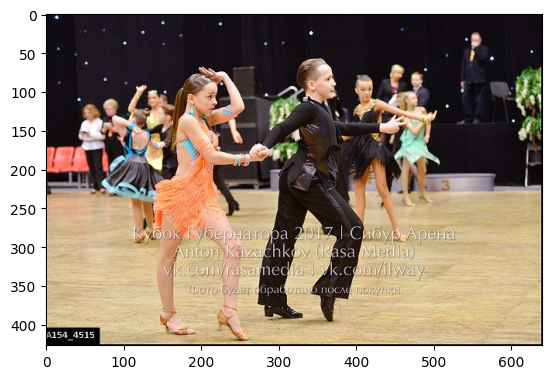

In [7]:
img = cv2.imread('imgs_dataset/La/7.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [8]:
TRAIN_PERCENT = 0.8
BATCH_SIZE = 32

In [9]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='imgs_dataset/', transform=transform)

classes = dataset.classes  # Список классов
class_to_idx = dataset.class_to_idx  # Словарь {имя_класса: индекс}

targets = dataset.targets  # Индексы классов для всех изображений


class_counts = Counter(targets) # Сколько в каждом классе элементов

for class_name, class_index in class_to_idx.items():
    print(f"{class_name}: {class_counts[class_index]} картинок")

train_size = int(TRAIN_PERCENT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



La: 2736 картинок
St: 2584 картинок


In [10]:
DROPOUT = 0.3

In [11]:
def create_conv_layer(in_channels, out_channels):
    return nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1)

def create_pool_layer(size):
    return nn.MaxPool2d(kernel_size=size, stride=size)

In [12]:
# моя модель

class BallroomClassifier(nn.Module):
    def __init__(self):
        super(BallroomClassifier, self).__init__()

        self.conv16 = create_conv_layer(3, 16)
        self.conv32_1 = create_conv_layer(16, 32)
        self.conv32_2 = create_conv_layer(32, 32)

        self.pool4 = create_pool_layer(4)
        self.pool8 = create_pool_layer(8)

        self.fc1 = nn.Linear(1 * 1 * 32, 128)
        self.fc2 = nn.Linear(128, 1)

        self.dropout = nn.Dropout(DROPOUT)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv16(x) # ------------
        x = self.relu(x)

        x = self.pool4(x)

        x = self.conv32_1(x)
        x = self.relu(x)

        x = self.pool4(x)

        x = self.conv32_2(x)
        x = self.relu(x)

        x = self.pool8(x) # ---------

        saved_embedding = x
        x = x.view(-1, 1 * 1 * 32)

        x = self.fc1(x) # -------------
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = torch.sigmoid(x) # вероятность принадлежности классу 1 -----------

        return x, saved_embedding


In [23]:
def validate_custom(model, dataloader, criterion):
    model.eval()

    right_preds = 0
    total_preds = 0
    total_loss = 0.0

    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).float()

            outputs, _ = model(images)
            outputs = outputs.squeeze(1)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predicted = (outputs >= 0.5).float()
            total_preds += labels.size(0) # BATCH_SIZE
            right_preds += (predicted == labels).sum().item()

            all_outputs.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = right_preds / total_preds * 100

    return accuracy, total_loss/len(dataloader), np.array(all_outputs), np.array(all_labels)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [15]:
model = BallroomClassifier().to(device)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = ExponentialLR(optimizer, gamma=0.9)
train_loss_arr = []
test_loss_arr = []
test_accuracy_arr = []

In [16]:
EPOCH_NUM = 35

In [ ]:
# обучение модели

writer = SummaryWriter(log_dir="logs")

embeddings_arr = []
labels_arr = []

for epoch in range(EPOCH_NUM):
    model.train()
    running_loss = 0.0

    with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCH_NUM}", unit="batch") as pbar:
        for images, labels in train_loader:
            labels_arr.extend(labels.numpy())

            images, labels = images.to(device), labels.to(device).float()  # Перенос данных на cpu

            outputs, embeddings = model(images)
            for batch_num in range(BATCH_SIZE): # итерация по эмбеддингам в батче из 32 эмбеддингов
                embedding = []
                for fm in embeddings[batch_num]: # итерация по 32 feature maps of 1*1
                    embedding.append(fm[0][0].item())
                embeddings_arr.append(embedding)

            outputs = outputs.squeeze(1)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pbar.update(1)

        scheduler.step()

        test_accuracy, test_loss = validate_custom(model, test_loader, criterion)
        test_loss_arr.append(test_loss)
        test_accuracy_arr.append(test_accuracy)
        writer.add_scalar("TEST Accuracy", test_accuracy, epoch)
        writer.add_scalar("TEST Loss", test_loss, epoch)

        train_loss = running_loss/len(train_loader)
        print(f"Epoch [{epoch+1}/{EPOCH_NUM}], Loss: {train_loss:.4f}")
        train_loss_arr.append(train_loss)
        writer.add_scalar("TRAIN Loss", train_loss, epoch)



writer.close()


In [18]:
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             448
              ReLU-2         [-1, 16, 128, 128]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6             [-1, 32, 8, 8]               0
            Conv2d-7             [-1, 32, 8, 8]           9,248
              ReLU-8             [-1, 32, 8, 8]               0
         MaxPool2d-9             [-1, 32, 1, 1]               0
           Linear-10                  [-1, 128]           4,224
             ReLU-11                  [-1, 128]               0
          Dropout-12                  [-1, 128]               0
           Linear-13                    [-1, 1]             129
Total params: 18,689
Trainable params: 

Text(0, 0.5, 'Loss')

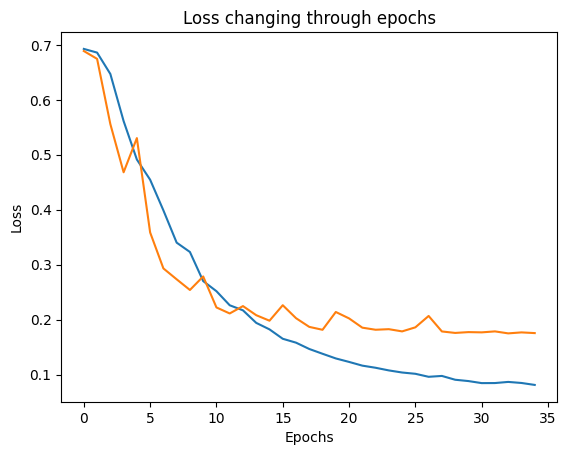

In [19]:
plt.title('Loss changing through epochs')
plt.plot(train_loss_arr, label='TRAIN Loss')
plt.plot(test_loss_arr, label='TEST Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

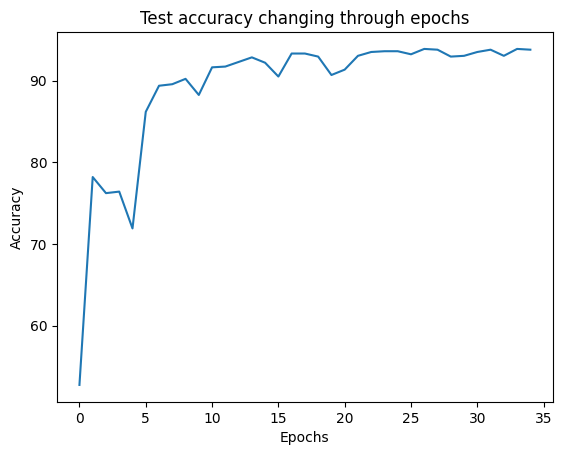

In [20]:
plt.title('Test accuracy changing through epochs')
plt.plot(test_accuracy_arr)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

Переобучения нет, видим хорошие показатели и на train и на test

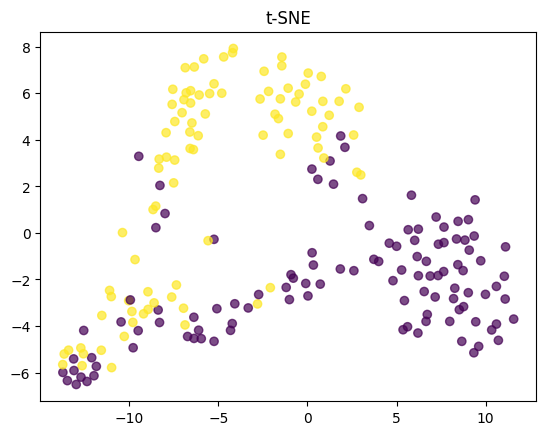

In [21]:
random_indices = np.random.choice(len(embeddings_arr), size=200, replace=False)
random_embeddings = np.array(embeddings_arr)[random_indices]
random_labels = np.array(labels_arr)[random_indices]

tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(random_embeddings)

scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=random_labels, alpha=0.7)

plt.title('t-SNE')
plt.show()

Отображение в 2мерное пространство показывает, что модель выдает качественные эмбеддинги для картинок. Видно разделение на 2 кластера

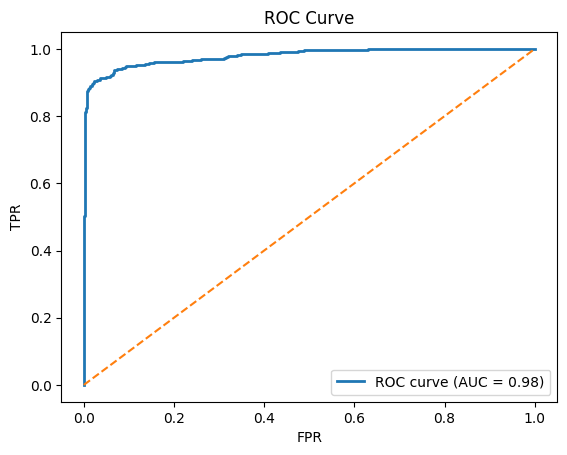

Confusion Matrix:
[[539  22]
 [ 44 459]]
Recall: 0.9125
F1-score: 0.9329
AUC: 0.9796


In [24]:
# test metrics

_, _, all_outputs, all_labels = validate_custom(model, test_loader, criterion)

# roc auc
fpr, tpr, _ = roc_curve(all_labels, all_outputs)
roc_auc = roc_auc_score(all_labels, all_outputs)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()


predicted_classes = (all_outputs >= 0.5).astype(int)

# f1, confusion matrix, recall

cm = confusion_matrix(all_labels, predicted_classes)
recall = recall_score(all_labels, predicted_classes)
f1 = f1_score(all_labels, predicted_classes)

print("Confusion Matrix:")
print(cm)
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")


In [27]:
DROPOUT = 0.3

In [28]:
# предобученная модель, я добавила к ней сверху только линейные слои

class PretrainedClassifier(nn.Module):
    def __init__(self):
        super(PretrainedClassifier, self).__init__()
        self.model = resnet50(pretrained=True)

        # "Замораживаем" все веса для ускорения обучения (мы считаем что они уже хорошо обучены)
        for param in self.model.parameters():
            param.requires_grad = False

        self.fc1 = nn.Linear(1000, 128)
        self.fc2 = nn.Linear(128, 1)

        self.dropout = nn.Dropout(DROPOUT)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.model(x)

        saved_embedding = x

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = torch.sigmoid(x)

        return x, saved_embedding


In [29]:
def validate_pretrain(model, dataloader, criterion):
    model.eval()

    right_preds = 0
    total_preds = 0
    total_loss = 0.0

    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).float()

            outputs = model(images)[0].squeeze(1)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predicted = (outputs >= 0.5).float()
            total_preds += labels.size(0) # BATCH_SIZE
            right_preds += (predicted == labels).sum().item()

            all_outputs.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = right_preds / total_preds * 100

    return accuracy, total_loss/len(dataloader), np.array(all_outputs), np.array(all_labels)

In [34]:
model = PretrainedClassifier().to(device)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
scheduler = ExponentialLR(optimizer, gamma=0.9)
train_loss_arr = []
test_loss_arr = []
test_accuracy_arr = []

C:\Users\Ксения\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Ксения\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
EPOCH_NUM = 25

In [ ]:
# обучение

embeddings_arr = []
labels_arr = []
for epoch in range(EPOCH_NUM):
    model.train()
    running_loss = 0.0

    with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCH_NUM}", unit="batch") as pbar:
        for images, labels in train_loader:
            labels_arr.extend(labels.numpy())

            images, labels = images.to(device), labels.to(device).float()  # Перенос данных на cpu

            outputs, embeddings = model(images)
            outputs = outputs.squeeze(1)

            for batch_num in range(BATCH_SIZE):
                embeddings_arr.append(embeddings[batch_num].detach().numpy())
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pbar.update(1)

        scheduler.step()

        test_accuracy, test_loss, _, _ = validate_pretrain(model, test_loader, criterion)
        test_loss_arr.append(test_loss)
        test_accuracy_arr.append(test_accuracy)

        train_loss = running_loss/len(train_loader)
        print(f"Epoch [{epoch+1}/{EPOCH_NUM}], Loss: {train_loss:.4f}")
        train_loss_arr.append(train_loss)


Text(0, 0.5, 'Loss')

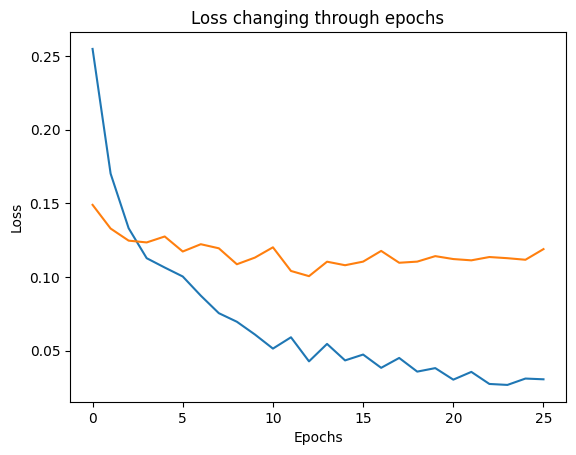

In [37]:
plt.title('Loss changing through epochs')
plt.plot(train_loss_arr, label='TRAIN Loss')
plt.plot(test_loss_arr, label='TEST Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

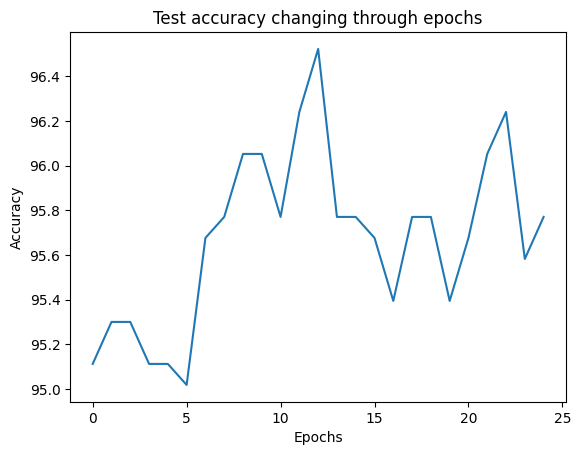

In [41]:
plt.title('Test accuracy changing through epochs')
plt.plot(test_accuracy_arr)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

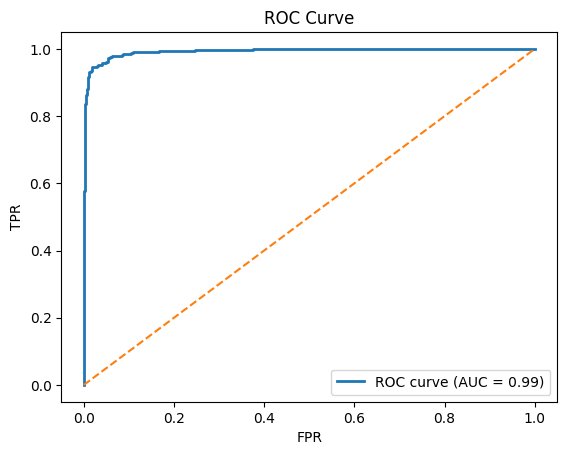

Confusion Matrix:
[[531  30]
 [ 18 485]]
Recall: 0.9642
F1-score: 0.9528
AUC: 0.9933


In [39]:
# test metrics

_, _, all_outputs, all_labels = validate_pretrain(model, test_loader, criterion)

# roc auc
fpr, tpr, _ = roc_curve(all_labels, all_outputs)
roc_auc = roc_auc_score(all_labels, all_outputs)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()


predicted_classes = (all_outputs >= 0.5).astype(int)

# f1, confusion matrix, recall

cm = confusion_matrix(all_labels, predicted_classes)
recall = recall_score(all_labels, predicted_classes)
f1 = f1_score(all_labels, predicted_classes)

print("Confusion Matrix:")
print(cm)
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")


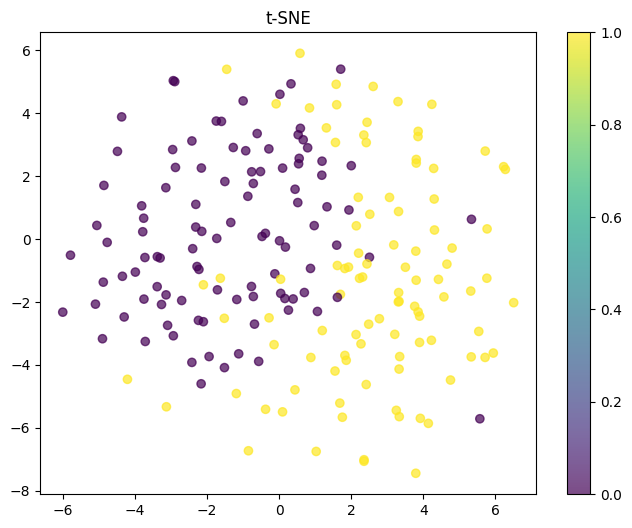

In [43]:
random_indices = np.random.choice(len(embeddings_arr), size=200, replace=False)

random_embeddings = np.array(embeddings_arr)[random_indices]
random_labels = np.array(labels_arr)[random_indices]

tsne = TSNE(n_components=2, random_state=42)
data_2d = tsne.fit_transform(random_embeddings)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=random_labels, cmap='viridis', alpha=0.7)

plt.title('t-SNE')
plt.show()

In [44]:
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           9,408
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]           4,096
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]          16,384
      BatchNorm2d-12          [-1, 256, 32, 32]             512
           Conv2d-13          [-1, 256, 32, 32]          16,384
      BatchNorm2d-14          [-1, 256,

По графикам, которые показывают хорошие метрики модели практически с первых эпох, видно, что модель предобучена. Метрики моей и изначально предобученной моделей после обучения различаются несильно, но у предобученной они все-таки немного лучше. Время обучения предобученной модели было дольше